In [2]:
REPO_URL = "https://github.com/anuragupperwal/KD_MoE_CKA.git"
REPO_NAME = "KD_MoE_CKA"

!rm -rf /kaggle/working/$REPO_NAME
!git clone --depth 1 "$REPO_URL" "/kaggle/working/$REPO_NAME"
!ls -la "/kaggle/working/$REPO_NAME"


Cloning into '/kaggle/working/KD_MoE_CKA'...
remote: Enumerating objects: 15, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 15 (delta 1), reused 11 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (15/15), 5.88 KiB | 5.88 MiB/s, done.
Resolving deltas: 100% (1/1), done.
total 32
drwxr-xr-x 4 root root 4096 Oct  7 15:58 .
drwxr-xr-x 4 root root 4096 Oct  7 15:58 ..
drwxr-xr-x 8 root root 4096 Oct  7 15:58 .git
-rw-r--r-- 1 root root  180 Oct  7 15:58 .gitignore
-rw-r--r-- 1 root root 4186 Oct  7 15:58 README.md
-rw-r--r-- 1 root root   28 Oct  7 15:58 requirements.txt
drwxr-xr-x 5 root root 4096 Oct  7 15:58 src


In [3]:
# to reload github repo
%cd /kaggle/working/KD_MoE_CKA
!git fetch origin
!git pull origin main   # or replace 'main' with 'master' or your branch name

/kaggle/working/KD_MoE_CKA
From https://github.com/anuragupperwal/KD_MoE_CKA
 * branch            main       -> FETCH_HEAD
Already up to date.


In [3]:
%cd /kaggle/working/KD_MoE_CKA

# Speed + disk hygiene: set local HF cache
import os
os.environ["HF_HOME"] = "/kaggle/working/.hf_cache"
# os.environ["TRANSFORMERS_CACHE"] = "/kaggle/working/.hf_cache"

# Install from your requirements.txt 
!pip -q install -r requirements.txt

# (Optional but useful) Show versions
import torch, transformers, datasets, platform
print("Torch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)
print("Python:", platform.python_version())

/kaggle/working/KD_MoE_CKA
Torch: 2.6.0+cu124
Transformers: 4.52.4
Datasets: 3.6.0
Python: 3.11.13


In [ ]:
!pip install -U transformers accelerate datasets sentencepiece --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 92.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.9/374.9 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 503.6/503.6 kB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 66.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 564.3/564.3 kB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 MB 46.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 101.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 93.4 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 67.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 51.8 MB/s eta

In [4]:
import sys, os
sys.path.append("/kaggle/working/KD_MoE_CKA/src")

# Optional: verify imports
from data.dataset_loader import get_dataset_and_tokenizer
from trainers.trainer import train_model

print("Imports OK")

Imports OK


In [5]:

OUTPUT_DIR = "/kaggle/working/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Example subfolders
CKPT_DIR = os.path.join(OUTPUT_DIR, "models/teacher")
RESULTS_DIR = os.path.join(OUTPUT_DIR, "results")
PLOTS_DIR = os.path.join(OUTPUT_DIR, "plots")
for d in [CKPT_DIR, RESULTS_DIR, PLOTS_DIR]:
    os.makedirs(d, exist_ok=True)

# change theses paths from colab to kaggel 

## for next cell to run this
 sys.path.append(f"{MODELS_DIR}/teacher")

## For saving checkpoints
 save_path="/kaggle/working/models/teacher"

## checkpoint_dir = "/kaggle/working/models/teacher"

## For results
RESULTS_DIR = "/kaggle/working/results"
PLOTS_DIR  = "/kaggle/working/plots"



!kaggle datasets create -p /kaggle/working/models -r zip -m "Initial upload" --dir-mode tar \
     -d yourusername/thesis-checkpoints
!kaggle datasets version -p /kaggle/working/models -m "Updated teacher checkpoints"
!kaggle datasets version -p /kaggle/working/results -m "Updated training results"



In [6]:
import os, shutil

os.environ["TOKENIZERS_PARALLELISM"] = "false"
# Make sure ~/.kaggle exists
os.makedirs("/root/.kaggle", exist_ok=True)

# Copy from your dataset input location
shutil.copy("/kaggle/input/thesis-dir/kaggle.json", "/root/.kaggle/")

# Set correct permissions
os.chmod("/root/.kaggle/kaggle.json", 0o600)

from kaggle.api.kaggle_api_extended import KaggleApi
api = KaggleApi()
api.authenticate()

print("Kaggle API key set up at /root/.kaggle/kaggle.json")


Kaggle API key set up at /root/.kaggle/kaggle.json


In [7]:
# !kaggle datasets list -s titanic

In [ ]:
#login here to  huggingface-cli login 

The token has not been saved to the git credentials helper. Pass `add_to_git_credential=True` in this function directly or `--add-to-git-credential` if using via `huggingface-cli` if you want to set the git credential as well.
Token is valid (permission: fineGrained).
The token `productivity_agent` has been saved to /kaggle/working/.hf_cache/stored_tokens
Your token has been saved to /kaggle/working/.hf_cache/token
Login successful.
The current active token is: `productivity_agent`


Resume: None


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

...

Epoch 1:   0%|          | 0/3750 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Step 100, Loss = 0.1480
Step 200, Loss = 0.1096
Step 300, Loss = 0.2121
Step 400, Loss = 0.1175
Step 500, Loss = 0.1155
Step 600, Loss = 0.6627
Step 700, Loss = 0.1529
Step 800, Loss = 0.1924
Step 900, Loss = 0.3137
Step 1000, Loss = 0.0489
Step 1100, Loss = 0.1996
Step 1200, Loss = 0.2247
Step 1300, Loss = 0.1348
Step 1400, Loss = 0.0720
Step 1500, Loss = 0.0958
Step 1600, Loss = 0.0635
Step 1700, Loss = 0.2077
Step 1800, Loss = 0.2094
Step 1900, Loss = 0.2756
Step 2000, Loss = 0.1965
Step 2100, Loss = 0.0750
Step 2200, Loss = 0.2681
Step 2300, Loss = 0.0928
Step 2400, Loss = 0.1732
Step 2500, Loss = 0.2658
Step 2600, Loss = 0.2619
Step 2700, Loss = 0.2581
Step 2800, Loss = 0.2692
Step 2900, Loss = 0.1041
Step 3000, Loss = 0.1548
Step 3100, Loss = 0.0859
Step 3200, Loss = 0.1760
Step 3300, Loss = 0.3079
Step 3400, Loss = 0.2586
Step 3500, Loss = 0.2666
Step 3600, Loss = 0.4105
Step 3700, Loss = 0.0727
Epoch 1/1 | Train Loss: 0.1977 | Val Loss: 0.1523 | Val Acc: 0.9486 | F1(macro): 0.9

Uploading...:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Pushed epoch 1 to HuggingFace Hub
Final Val Acc: 0.9486 | F1(macro): 0.9485 | F1(weighted): 0.9485


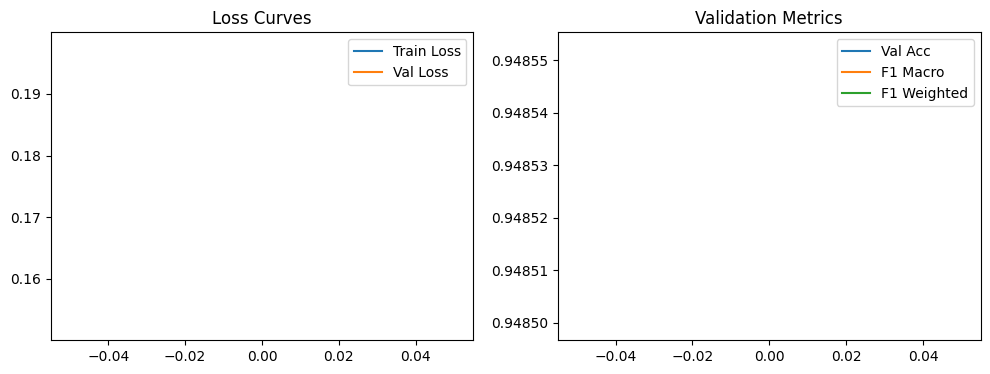

In [9]:
import json
import os, glob, sys, torch
import matplotlib.pyplot as plt

sys.path.append("/kaggle/working/KD_MoE_CKA/src")
from data.dataset_loader import get_dataset_and_tokenizer
from models.teacher_model import get_teacher_model
from trainers.utils import get_dataloaders
from trainers.trainer import train_model
from trainers.trainer import evaluate_model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Find latest checkpoint
checkpoint_dir = "/kaggle/working/models"
all_ckpts = glob.glob(f"{checkpoint_dir}/teacher_*/checkpoint.pt")
resume_ckpt = max(all_ckpts, key=os.path.getmtime) if all_ckpts else None
print("Resume:", resume_ckpt)

# Data
train_ds, val_ds, test_ds, tokenizer = get_dataset_and_tokenizer(
    "roberta-large",
    train_split_ratio=0.1   #train-0.9, val-0.1
)
train_loader, val_loader = get_dataloaders(train_ds, val_ds, batch_size=32)

# Model
teacher = get_teacher_model("roberta-large").to(device)

if torch.cuda.device_count() > 1:
    print("Using", torch.cuda.device_count(), "GPUs with DataParallel")
    teacher = torch.nn.DataParallel(teacher)


# Train
teacher, train_losses, val_accs, val_losses, f1_macro_list, f1_weighted_list = train_model(
    model=teacher,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=1,               
    lr=2e-5,
    device=device,
    save_path="/kaggle/working/models/teacher",
    save_every=10000,
    resume_checkpoint=None,
    use_amp=True,              
    tokenizer=tokenizer,
    repo_id = "anuragupperwal/teacher-finetuned-roberta"
)

# Save metrics
import json, time
RESULTS_DIR = "/kaggle/working/results"
PLOTS_DIR  = "/kaggle/working/plots"
os.makedirs(RESULTS_DIR, exist_ok=True)
results = {
    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
    "train_losses": train_losses,
    "val_losses": val_losses,
    "val_accs": val_accs,
    "val_f1_macro": f1_macro_list,
    "val_f1_weighted": f1_weighted_list
}
with open(os.path.join(RESULTS_DIR, "results_teacher.json"), "w") as f:
    json.dump(results, f, indent=2)

if val_accs:
    print(f"Final Val Acc: {val_accs[-1]:.4f} | F1(macro): {f1_macro_list[-1]:.4f} | F1(weighted): {f1_weighted_list[-1]:.4f}")
else:
    print("No validation metrics recorded.")


plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend(); plt.title("Loss Curves")

plt.subplot(1,2,2)
plt.plot(val_accs, label="Val Acc")
plt.plot(f1_macro_list, label="F1 Macro")
plt.plot(f1_weighted_list, label="F1 Weighted")
plt.legend(); plt.title("Validation Metrics")

plt.show()


#Evaluate on test set
print("\nEvaluating final model on AG News test set...")
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=32)

test_acc, test_loss, test_f1_macro, test_f1_weighted = evaluate_model(teacher, test_loader, device)

print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")
print(f"F1 Macro: {test_f1_macro:.4f}")
print(f"F1 Weighted: {test_f1_weighted:.4f}")

with open("/kaggle/working/outputs/results/test_metrics_teacher.json", "w") as f:
    json.dump({
        "test_acc": test_acc,
        "test_loss": test_loss,
        "f1_macro": test_f1_macro,
        "f1_weighted": test_f1_weighted
    }, f, indent=2)

In [ ]:
# ✅ Step 4: Evaluate on the held-out test set
from trainers.trainer import evaluate_model

print("\n🔍 Evaluating final model on AG News test set...")
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=32)

test_acc, test_loss, test_f1_macro, test_f1_weighted = evaluate_model(teacher, test_loader, device)

print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"✅ Test Loss: {test_loss:.4f}")
print(f"✅ F1 Macro: {test_f1_macro:.4f}")
print(f"✅ F1 Weighted: {test_f1_weighted:.4f}")

import json
with open("/kaggle/working/results/test_metrics_teacher.json", "w") as f:
    json.dump({
        "test_acc": test_acc,
        "test_loss": test_loss,
        "f1_macro": test_f1_macro,
        "f1_weighted": test_f1_weighted
    }, f, indent=2)


🔍 Evaluating final model on AG News test set...


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(



✅ Test Accuracy: 0.9486
✅ Test Loss: 0.1523
✅ F1 Macro: 0.9485
✅ F1 Weighted: 0.9485


In [10]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch

# Load from HuggingFace Hub
model_name = "anuragupperwal/teacher-finetuned-roberta"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

# Put model on GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/893 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 1024, padding_idx=1)
      (position_embeddings): Embedding(514, 1024, padding_idx=1)
      (token_type_embeddings): Embedding(1, 1024)
      (LayerNorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-23): 24 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=1024, out_features=1024, bias=True)
              (key): Linear(in_features=1024, out_features=1024, bias=True)
              (value): Linear(in_features=1024, out_features=1024, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=1024, out_features=1024, bias=Tru

In [11]:
import torch.nn.functional as F

texts = [
    "The crop needs irrigation due to lack of rainfall.",
    "Market prices for wheat are increasing this week.",
    "The soil quality in this region is very poor."
]

# Tokenize
inputs = tokenizer(texts, padding=True, truncation=True, return_tensors="pt").to(device)

# Inference
with torch.no_grad():
    outputs = model(**inputs)
    probs = F.softmax(outputs.logits, dim=-1)
    preds = torch.argmax(probs, dim=-1)

print("Predictions:", preds.cpu().tolist())
print("Probabilities:", probs.cpu().numpy())

Predictions: [2, 2, 3]
Probabilities: [[7.7488527e-02 4.8371698e-03 5.2739120e-01 3.9028311e-01]
 [2.8295135e-02 3.7799956e-04 9.6680719e-01 4.5196768e-03]
 [6.7270592e-02 3.1169557e-03 4.2467382e-02 8.8714510e-01]]


In [ ]:
# to save the outputs
!kaggle datasets create -p /kaggle/working/models -r zip -m "Initial teacher checkpoints"
!kaggle datasets create -p /kaggle/working/results -r zip -m "Initial results"
# ✅ Update Kaggle dataset (replace "yourusername/thesis-checkpoints" with yours)
!kaggle datasets version -p /kaggle/working/models -m "Updated teacher checkpoints"
!kaggle datasets version -p /kaggle/working/results -m "Updated training results"

In [9]:
#to loag kaggle.json correctly - no of any use now
import os, json, zipfile
from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()
api.authenticate()

# Zip your results
!zip -r results.zip /kaggle/working/outputs

# Upload as dataset
api.dataset_create_version(
    "results.zip",
    version_notes="teacher model run results",
    convert_to_csv=False
)

  adding: kaggle/working/outputs/ (stored 0%)
  adding: kaggle/working/outputs/results/ (stored 0%)
  adding: kaggle/working/outputs/plots/ (stored 0%)
  adding: kaggle/working/outputs/models/ (stored 0%)
  adding: kaggle/working/outputs/models/teacher/ (stored 0%)


ValueError: Invalid folder: results.zip

In [10]:
#bekar
import json, time
results = {
    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
    "train_losses": train_losses,
    "val_accs": val_accs,
    "val_losses": val_losses
}

with open("/content/drive/MyDrive/thesis_project/results_teacher.json", "w") as f:
    json.dump(results, f, indent=4)

print("Validation Accuracies:", val_accs)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/thesis_project/results_teacher.json'

In [ ]:
#load model checkpoint and evaluate

import torch
from models.teacher_model import get_teacher_model
from data.dataset_loader import get_dataset_and_tokenizer
from trainers.utils import get_dataloaders
from trainers.trainer import evaluate_model
from collections import OrderedDict

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the same model architecture
model = get_teacher_model("roberta-large").to(device)



# Load checkpoint
ckpt_path = "/kaggle/working/models/teacher_epoch2/checkpoint.pt"
checkpoint = torch.load(ckpt_path, map_location=device)
# model.load_state_dict(checkpoint["model_state_dict"])

state_dict = checkpoint["model_state_dict"]
new_state_dict = OrderedDict()

for k, v in state_dict.items():
    # remove 'module.' prefix if it exists
    '''
    When you train with DataParallel, all weights in the state_dict are prefixed with "module."
    Later, if you create a plain RobertaForSequenceClassification, its keys don’t have "module.", 
    so PyTorch complains about unexpected keys and missing keys.
    '''
    new_key = k.replace("module.", "") if k.startswith("module.") else k
    new_state_dict[new_key] = v

model.load_state_dict(new_state_dict)
print("Loaded checkpoint without DataParallel prefixes")
model.eval()
print("Loaded checkpoint:", ckpt_path)


train_ds, val_ds, test_ds, tokenizer = get_dataset_and_tokenizer(
    "roberta-large",
    train_size=50000,
    val_size=7600
)
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=32)




val_acc, val_loss, f1_macro, f1_weighted = evaluate_model(model, test_loader, device)

print(f"Test Accuracy: {val_acc:.4f}")
print(f"Test Loss: {val_loss:.4f}")
print(f"F1 Macro: {f1_macro:.4f}")
print(f"F1 Weighted: {f1_weighted:.4f}")



# run inference

from transformers import AutoTokenizer
import torch.nn.functional as F

# use same tokenizer as training
tokenizer = AutoTokenizer.from_pretrained("roberta-large")
texts = [
    "The crop needs irrigation due to lack of rainfall.",
    "Market prices for wheat are increasing this week.",
    "The soil quality in this region is very poor."
]
inputs = tokenizer(texts, return_tensors="pt", padding=True, truncation=True).to(device)

with torch.no_grad():
    outputs = model(**inputs)
    probs = F.softmax(outputs.logits, dim=-1)
    preds = torch.argmax(probs, dim=-1) 

print("Prediction:", preds)
print("Probabilities:", probs.cpu().numpy())

#map class indices to labels
id2label = {0: "Weather", 1: "Market", 2: "Soil", 3: "Other"}
for text, pred in zip(texts, preds):
    print(f"Input: {text}")
    print(f"Prediction: {id2label[pred.item()]}")
    print()

In [ ]:
import matplotlib.pyplot as plt

# Load metrics from JSON
import json
with open("/content/drive/MyDrive/thesis_project/results_teacher.json", "r") as f:
    results = json.load(f)

train_losses = results["train_losses"]
val_losses = results["val_losses"]
val_accs = results["val_accs"]

epochs = range(1, len(train_losses) + 1)

# Plot Training & Validation Loss
plt.figure(figsize=(8,6))
plt.plot(epochs, train_losses, label="Train Loss", marker="o")
plt.plot(epochs, val_losses, label="Val Loss", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.savefig("/content/drive/MyDrive/thesis_project/plots_teacher_loss.png")
plt.show()

# Plot Validation Accuracy
plt.figure(figsize=(8,6))
plt.plot(epochs, val_accs, label="Val Accuracy", marker="o", color="green")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")
plt.legend()
plt.grid(True)
plt.savefig("/content/drive/MyDrive/thesis_project/plots_teacher_accuracy.png")
plt.show()

In [ ]:
!ls /content/drive/MyDrive/thesis_project/models/
!ls /content/drive/MyDrive/thesis_project/

In [ ]:
#That reloads your trained model exactly where you left off.
from transformers import AutoModelForSequenceClassification

teacher = AutoModelForSequenceClassification.from_pretrained(
    "/content/drive/MyDrive/thesis_project/models/teacher_epoch1"
)

In [ ]:

OUTPUT_DIR = "/kaggle/working/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Example subfolders
STUD_CKPT_DIR = os.path.join(OUTPUT_DIR, "models/student")
RESULTS_DIR = os.path.join(OUTPUT_DIR, "results")
PLOTS_DIR = os.path.join(OUTPUT_DIR, "plots")
for d in [STUD_CKPT_DIR, RESULTS_DIR, PLOTS_DIR]:
    os.makedirs(d, exist_ok=True)

In [ ]:
# student model

import os, glob, sys, torch, json, time
import matplotlib.pyplot as plt

# Ensure src path is added
sys.path.append("/kaggle/working/KD_MoE_CKA/src")

from data.dataset_loader import get_dataset_and_tokenizer
from models.student_model import get_student_model
from trainers.utils import get_dataloaders
from trainers.trainer import train_model, evaluate_model   # include evaluate_model

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


checkpoint_dir = "/kaggle/working/models/student"
all_ckpts = glob.glob(f"{checkpoint_dir}_epoch*/checkpoint.pt")
resume_ckpt = max(all_ckpts, key=os.path.getmtime) if all_ckpts else None
print("Resume:", resume_ckpt)


train_ds, val_ds, test_ds, tokenizer = get_dataset_and_tokenizer(
    "distilbert-base-uncased",
    train_split_ratio=0.1  
)

train_loader, val_loader = get_dataloaders(train_ds, val_ds, batch_size=64)


student = get_student_model("distilbert-base-uncased").to(device)

if torch.cuda.device_count() > 1:
    print("Using", torch.cuda.device_count(), "GPUs with DataParallel")
    student = torch.nn.DataParallel(student)


student, train_losses, val_accs, val_losses, f1_macro_list, f1_weighted_list = train_model(
    model=student,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=1,
    lr=2e-5,
    device=device,
    save_path="/kaggle/working/models/student",
    save_every=10000,
    resume_checkpoint=None,
    use_amp=True,
    tokenizer=tokenizer,
    repo_id="anuragupperwal/student-finetuned-distilbert-base"
)


RESULTS_DIR = "/kaggle/working/student_results"
PLOTS_DIR = "/kaggle/working/student_plots"
os.makedirs(RESULTS_DIR, exist_ok=True)

results = {
    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
    "train_losses": train_losses,
    "val_losses": val_losses,
    "val_accs": val_accs,
    "val_f1_macro": f1_macro_list,
    "val_f1_weighted": f1_weighted_list
}
with open(os.path.join(RESULTS_DIR, "results_student.json"), "w") as f:
    json.dump(results, f, indent=2)

if val_accs:
    print(f"Final Val Acc: {val_accs[-1]:.4f} | F1(macro): {f1_macro_list[-1]:.4f} | F1(weighted): {f1_weighted_list[-1]:.4f}")
else:
    print("No validation metrics recorded.")


plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend(); plt.title("Loss Curves")

plt.subplot(1, 2, 2)
plt.plot(val_accs, label="Val Acc")
plt.plot(f1_macro_list, label="F1 Macro")
plt.plot(f1_weighted_list, label="F1 Weighted")
plt.legend(); plt.title("Validation Metrics")

plt.show()


#test-student
print("\nEvaluating final model on AG News test set...")
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=64)

test_acc, test_loss, test_f1_macro, test_f1_weighted = evaluate_model(student, test_loader, device)

print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")
print(f"F1 Macro: {test_f1_macro:.4f}")
print(f"F1 Weighted: {test_f1_weighted:.4f}")

# Save test results
os.makedirs("/kaggle/working/outputs/results", exist_ok=True)
with open("/kaggle/working/outputs/results/test_metrics_student.json", "w") as f:
    json.dump({
        "test_acc": test_acc,
        "test_loss": test_loss,
        "f1_macro": test_f1_macro,
        "f1_weighted": test_f1_weighted
    }, f, indent=2)

In [8]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch.nn.functional as F
import torch

# Load from HuggingFace Hub
model_name = "anuragupperwal/student-finetuned-distilbert-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

# Put model on GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()


texts = [
    "The crop needs irrigation due to lack of rainfall.",
    "Market prices for wheat are increasing this week.",
    "The soil quality in this region is very poor."
]


# Tokenize
inputs = tokenizer(texts, padding=True, truncation=True, return_tensors="pt").to(device)

# Inference
with torch.no_grad():
    outputs = model(**inputs)
    probs = F.softmax(outputs.logits, dim=-1)
    preds = torch.argmax(probs, dim=-1)

print("Predictions:", preds.cpu().tolist())
print("Probabilities:", probs.cpu().numpy())

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/761 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Predictions: [3, 3, 3]
Probabilities: [[0.25245646 0.20810266 0.26357323 0.2758676 ]
 [0.246686   0.20629434 0.2562886  0.2907311 ]
 [0.23722333 0.2359156  0.24661514 0.28024593]]


# Comparison of the finetuned Teacher and Student model


In [ ]:
import torch, numpy as np, pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import (accuracy_score, f1_score, precision_recall_fscore_support,
                             confusion_matrix, roc_auc_score, classification_report)
from tqdm.auto import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

teacher_repo = "anuragupperwal/teacher-finetuned-roberta"
student_repo = "anuragupperwal/student-finetuned-distilbert-base"

teacher_tok = AutoTokenizer.from_pretrained(teacher_repo)
teacher = AutoModelForSequenceClassification.from_pretrained(teacher_repo).to(DEVICE).eval()

student_tok = AutoTokenizer.from_pretrained(student_repo)
student = AutoModelForSequenceClassification.from_pretrained(student_repo).to(DEVICE).eval()

id2label = {0: "Weather", 1: "Market", 2: "Soil", 3: "Other"}
num_labels = len(id2label)